In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv('wine_data.csv')
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

print (x)
print (y)

[[ 7.4    0.7    0.    ...  3.51   0.56   9.4  ]
 [ 7.8    0.88   0.    ...  3.2    0.68   9.8  ]
 [ 7.8    0.76   0.04  ...  3.26   0.65   9.8  ]
 ...
 [ 6.3    0.51   0.13  ...  3.42   0.75  11.   ]
 [ 5.9    0.645  0.12  ...  3.57   0.71  10.2  ]
 [ 6.     0.31   0.47  ...  3.39   0.66  11.   ]]
[5 5 5 ... 6 5 6]


In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)
print(x_train_scaled)
print(x_test_scaled)

[[ 0.90103398  0.05480282  0.9094138  ...  0.52091013 -0.22358408
  -0.95579434]
 [ 1.41998736 -1.47967601  0.9094138  ... -1.16841553 -0.68130963
  -0.76727388]
 [ 0.90103398 -0.98645067  1.4208416  ... -0.3237527   0.74908272
   0.17532846]
 ...
 [-0.25219574  0.21921126  0.19341488 ... -0.12883051  0.17692578
  -0.86153411]
 [ 2.68854005 -0.32881689  1.11398492 ... -0.06385645  0.11971008
   2.15479335]
 [ 0.84337249  2.46612668  0.24455766 ... -0.38872677 -1.0246038
  -0.95579434]]
[[ 1.41998736 -0.32881689  0.80712824 ... -0.90851928  0.57743564
   0.36384892]
 [-0.13687277  1.58928164 -1.39201131 ...  0.32598793 -0.73852533
  -0.76727388]
 [ 0.43974209 -1.31526756  0.29570044 ... -0.3237527   1.03516119
   1.21219102]
 ...
 [ 0.43974209 -1.04125349  0.75598546 ... -0.84354521 -0.62409394
   0.92941032]
 [ 0.43974209  1.28786615 -1.18744019 ... -0.12883051 -0.68130963
  -0.67301364]
 [-0.07921128 -1.15085912  0.75598546 ... -0.25877864 -0.62409394
   1.77775242]]


In [11]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt.fit(x_train_scaled,y_train)
y_dt = dt.predict(x_test_scaled)

result_dt = pd.DataFrame({'Actual': y_test, 'Predicted': y_dt})
print(result_dt)

     Actual  Predicted
0         6          5
1         5          5
2         7          7
3         6          5
4         5          5
..      ...        ...
315       6          7
316       4          7
317       5          6
318       4          5
319       6          7

[320 rows x 2 columns]


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
y_rf = rf.predict(x_test_scaled)

result_rf = pd.DataFrame({'Actual': y_test, 'Predicted': y_dt})
print(result_rf)

     Actual  Predicted
0         6          5
1         5          5
2         7          7
3         6          5
4         5          5
..      ...        ...
315       6          7
316       4          7
317       5          6
318       4          5
319       6          7

[320 rows x 2 columns]


           Model  Accuracy  R2 Score
0  Decision Tree  0.634375 -0.042648
1  Random Forest  0.718750  0.334016


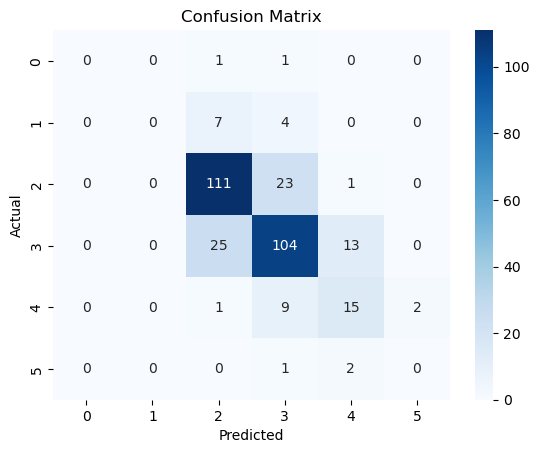

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score

acc_dt = accuracy_score(y_test, y_dt)
acc_rf = accuracy_score(y_test, y_rf)
r2_dt = r2_score(y_test, y_dt)
r2_rf = r2_score(y_test, y_rf)

compare = pd.DataFrame(
    {'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [acc_dt, acc_rf],
     'R2 Score' : [r2_dt, r2_rf]})
print(compare)

cm = confusion_matrix(y_test, y_rf)
sns.heatmap(cm, annot=True,fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()